# CustomerIQ - Exploratory Data Analysis

Exploring the cleaned churn dataset (`data/processed/customers_clean.csv`) to understand customer behavior patterns and what correlates with churn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
%matplotlib inline

## 1. Load Data

In [2]:
df = pd.read_csv("../data/processed/customers_clean.csv")
print(df.shape)
df.head()

(2490, 17)


,customer_id,age,gender,location,tenure_months,monthly_spend,total_spend,login_frequency,support_tickets,product_usage,subscription_type,payment_method,discount_used,churn,customer_lifetime_value,monthly_spend_outlier,tenure_months_outlier
0,CUST101806,48,Female,Houston,34,132.19,4845.28,23.1,1,80.8,Enterprise,PayPal,False,0,7529.88,False,False
1,CUST100899,22,Female,Houston,14,38.67,525.99,12.3,2,65.4,Standard,Debit Card,False,0,1425.93,False,False
2,CUST100383,26,Male,Chicago,6,45.19,283.03,21.1,0,88.4,Standard,PayPal,False,0,1291.15,False,False
3,CUST100332,33,Male,Austin,5,84.03,407.34,25.2,0,79.5,Premium,Electronic Check,True,0,1425.41,False,False
4,CUST101769,42,Female,San Diego,12,47.92,585.52,16.6,0,67.0,Standard,PayPal,True,1,1532.57,False,False


## 2. Summary Statistics

In [3]:
numeric_cols = [
    "age", "tenure_months", "monthly_spend", "total_spend",
    "login_frequency", "support_tickets", "product_usage",
    "customer_lifetime_value",
]
df[numeric_cols].describe()

,age,tenure_months,monthly_spend,total_spend,login_frequency,support_tickets,product_usage,customer_lifetime_value
count,2490.000000,2490.000000,2490.000000,2490.000000,2490.000000,2490.000000,2490.000000,2490.000000
mean,41.613253,23.099598,54.125261,1273.314799,16.462369,0.968273,65.649598,2453.482225
std,12.475586,20.415878,38.071481,2668.458649,4.837391,1.041234,14.813353,2404.311926
min,18.000000,0.000000,5.000000,0.000000,1.300000,0.000000,9.500000,254.990000
25%,33.000000,7.000000,23.840000,249.300000,13.225000,0.000000,55.600000,1048.560000
50%,42.000000,17.000000,43.710000,656.760000,16.400000,1.000000,66.000000,1646.860000
75%,50.000000,33.000000,73.620000,1537.502500,19.900000,2.000000,75.600000,2880.145000
max,83.000000,72.000000,148.290000,104557.189930,32.000000,6.000000,100.000000,22351.540000


In [4]:
churn_rate = df["churn"].mean()
print(f"Overall churn rate: {churn_rate:.2%}")

Overall churn rate: 5.90%


## 3. Distributions

In [5]:
def plot_distribution(df, column, bins=30, color="#4C72B0"):
    """Histogram for one numeric column with mean/median reference lines."""
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(df[column].dropna(), bins=bins, color=color, edgecolor="white")
    ax.axvline(df[column].mean(), color="black", linestyle="--",
               label=f"mean={df[column].mean():.1f}")
    ax.axvline(df[column].median(), color="red", linestyle=":",
               label=f"median={df[column].median():.1f}")
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("count")
    ax.legend()
    fig.tight_layout()
    plt.show()

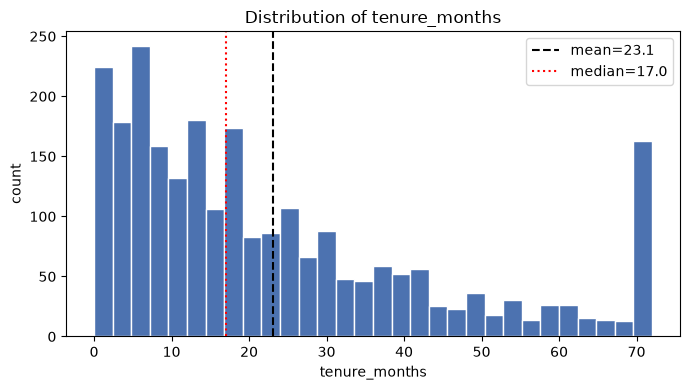

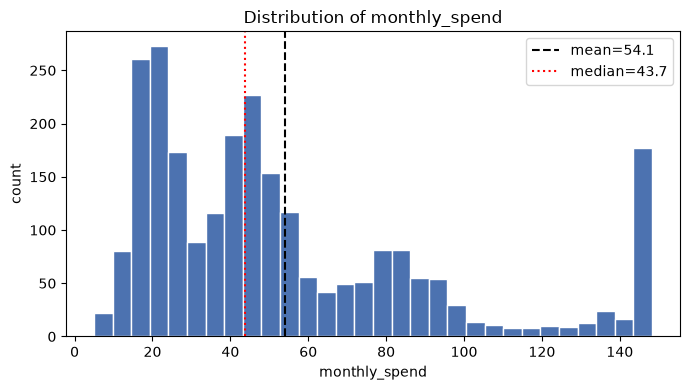

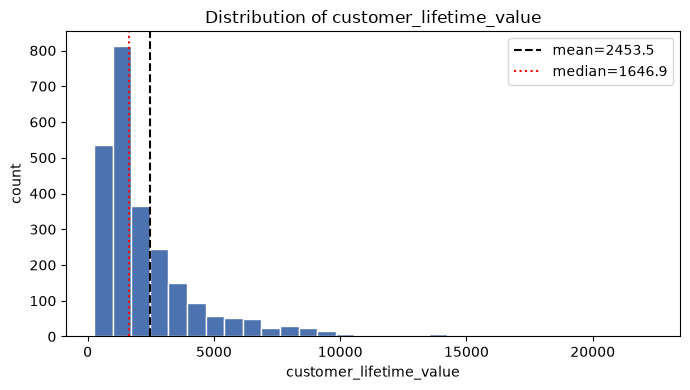

In [6]:
for col in ["tenure_months", "monthly_spend", "customer_lifetime_value"]:
    plot_distribution(df, col)

## 4. Correlation Heatmap

In [7]:
def plot_correlation_heatmap(df, columns, cmap="coolwarm"):
    """Annotated correlation heatmap for the given numeric columns."""
    corr = df[columns].corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)
    ax.set_xticks(range(len(columns)))
    ax.set_xticklabels(columns, rotation=45, ha="right")
    ax.set_yticks(range(len(columns)))
    ax.set_yticklabels(columns)
    for i in range(len(columns)):
        for j in range(len(columns)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, label="correlation")
    ax.set_title("Correlation heatmap of numeric features")
    fig.tight_layout()
    plt.show()
    return corr

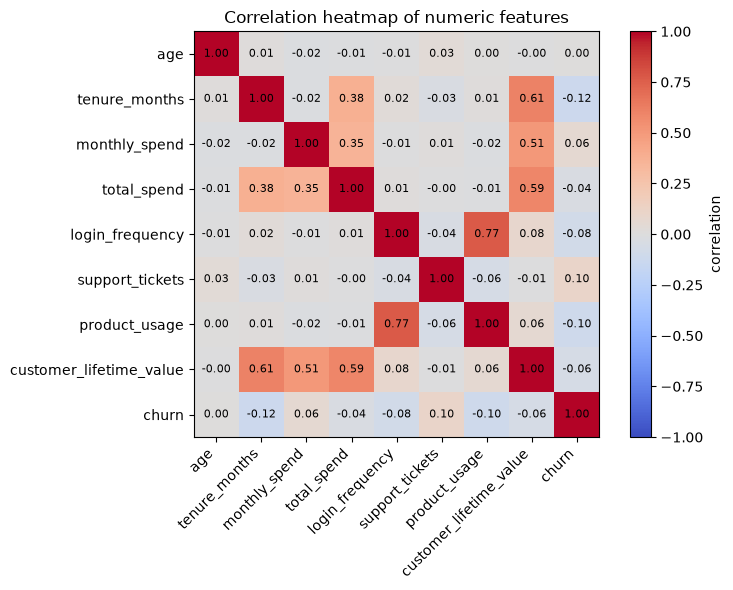

churn                      1.000000
support_tickets            0.104205
monthly_spend              0.055344
age                        0.001209
total_spend               -0.038039
customer_lifetime_value   -0.058576
login_frequency           -0.080000
product_usage             -0.104097
tenure_months             -0.121515
Name: churn, dtype: float64

In [8]:
corr_matrix = plot_correlation_heatmap(df, numeric_cols + ["churn"])
corr_matrix["churn"].sort_values(ascending=False)

## 5. Churn Rate by Subscription Type and Payment Method

In [9]:
def plot_churn_rate_by(df, group_col, color="#DD8452"):
    """Bar chart of churn rate grouped by a categorical column."""
    rates = df.groupby(group_col, observed=True)["churn"].mean().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(rates.index.astype(str), rates.values, color=color)
    ax.set_title(f"Churn rate by {group_col}")
    ax.set_ylabel("churn rate")
    ax.set_xlabel(group_col)
    ax.tick_params(axis="x", rotation=30)
    fig.tight_layout()
    plt.show()
    return rates

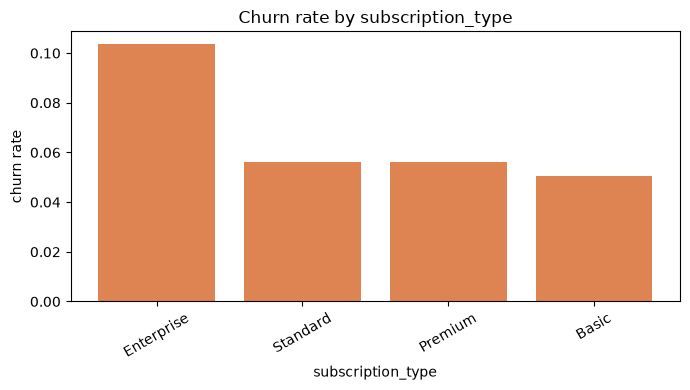

subscription_type
Enterprise    0.103586
Standard      0.056095
Premium       0.056017
Basic         0.050602
Name: churn, dtype: float64

In [10]:
plot_churn_rate_by(df, "subscription_type")

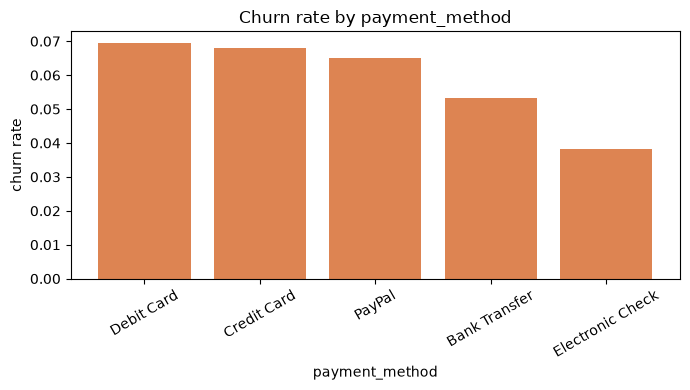

payment_method
Debit Card          0.069444
Credit Card         0.068053
PayPal              0.064990
Bank Transfer       0.053150
Electronic Check    0.038136
Name: churn, dtype: float64

In [11]:
plot_churn_rate_by(df, "payment_method")

## 6. Outliers

In [12]:
print("monthly_spend outliers flagged during cleaning:", df["monthly_spend_outlier"].sum())
print("tenure_months outliers flagged during cleaning:", df["tenure_months_outlier"].sum())

q1, q3 = df["customer_lifetime_value"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
clv_outliers = ((df["customer_lifetime_value"] < lower) | (df["customer_lifetime_value"] > upper)).sum()
print(f"customer_lifetime_value IQR bounds: [{lower:.0f}, {upper:.0f}] -> {clv_outliers} rows outside range ({clv_outliers / len(df):.1%})")

monthly_spend outliers flagged during cleaning: 161
tenure_months outliers flagged during cleaning: 25
customer_lifetime_value IQR bounds: [-1699, 5628] -> 211 rows outside range (8.5%)


**Outlier notes:**

- `monthly_spend` has 161 rows (~6.5%) flagged by the IQR rule applied during cleaning. These are dominated by Enterprise-tier customers, whose spend is naturally far above the Basic/Standard majority that sets the IQR bounds — the flag is mostly picking up a real subscription-tier effect, not bad data. Cleaning capped rather than dropped these rows, so the tier signal is preserved via `subscription_type`.
- `tenure_months` has only 25 rows (~1%) flagged, consistent with a small number of extreme values (200+ months) mixed in with a few genuinely long-tenured customers.
- `customer_lifetime_value` was **not** IQR-treated during cleaning but shows a similarly heavy right tail (~8.5% of rows above the upper bound), driven by the same high-spend, long-tenure customers. Worth revisiting whether CLV should also be capped or log-transformed before modeling.

## 7. Observations

- Overall churn rate is low (~5.9%), typical of a healthy subscriber base, but **Enterprise-tier customers churn almost twice as often (~10.4%)** as Basic/Standard/Premium (~5% each) — despite generating the most revenue per account, they are the highest-risk segment.
- `support_tickets` is the strongest *positive* driver of churn (r ≈ 0.10), while `tenure_months` (r ≈ -0.12), `product_usage` (r ≈ -0.10), and `login_frequency` (r ≈ -0.08) are the strongest *negative* drivers — newer, less-engaged customers who raise more support tickets are the clearest churn signal.
- Payment method shows a mild relationship with churn: Debit Card and Credit Card payers churn most (~6.8-6.9%) while Electronic Check payers churn least (~3.8%) — worth checking whether this reflects payment friction or is confounded with subscription tier.
- `monthly_spend` and `customer_lifetime_value` both have heavy right tails (6.5% and 8.5% of rows flagged as outliers respectively), largely explained by the Enterprise tier; churn models should likely use tier-normalized spend or log-transformed values rather than raw dollar amounts.